# Import Libraries

In [1]:
import numpy as np
import pandas as pd
from numba import njit, prange
import math

import matplotlib.pyplot as plt
import os
from aeon.utils.numba.general import z_normalise_series_2d
from aeon.distances import get_distance_function
import time

In [2]:
%load_ext autoreload
%autoreload 2
from ksfdtw.distance_measures import (
    euclidean_distance as ksfdtw_euclidean_distance,
    dtw as ksfdtw_dtw,
    usdtw_prime as usdtw_prime,
    psdtw_prime_vanilla as psdtw_prime_vanilla,
    psdtw_prime_parallel as psdtw_prime_parallel,
    psdtw_prime_parallel_bsf as psdtw_prime_parallel_bsf,
    psdtw_prime_parallel_bsf_lb as psdtw_prime_parallel_bsf_lb,
    psdtw_prime_parallel_bsf_lb2 as psdtw_prime_parallel_bsf_lb2,
    cut_based_distance as cut_based_distance,
)
from ksfdtw.utils import precision_at_k, nearest_neighbor_search
from aeon.distances import (
    euclidean_distance as aeon_euclidean_distance,
    squared_distance as aeon_squared_distance,
    dtw_distance as aeon_dtw_distance,
)

# Import Dataset

In [12]:
# The ten datasets used in the experiments:

# SonyAIBORobotSurface1 (Test)
# ECG200 (Train)
# MedicalImages (Train)
# CBF (Train)
# SwedishLeaf (Train)
# Plane (Train)
# PowerCons (Train)
# GunPoint (Train)
# Adiac (Train)
# Epilepsy (Train)

dataset_name = "ECG200"
# Target set
P = 3
l = 1.50
data = np.load(
    f"../data_processed/{dataset_name}_P{P}_uniform.npz",
    allow_pickle=True,
)
# Use Train or Test set?
trans_uniform_concatenated = data["X_train_trans_uniform_concatenated"]
# trans_uniform_concatenated = data["X_test_trans_uniform_concatenated"]

# Query set
# P = 3
data = np.load(
    f"../data_processed/{dataset_name}_P{P}_l{l:.2f}_random.npz",
    allow_pickle=True,
)
# Use Train or Test set?
trans_random_concatenated = data["X_train_trans_random_concatenated"]
# trans_random_concatenated = data["X_test_trans_random_concatenated"]

## Z-normalise the transformed series

In [13]:
trans_uniform_concatenated = z_normalise_series_2d(trans_uniform_concatenated)
trans_random_concatenated = z_normalise_series_2d(trans_random_concatenated)

In [14]:
# Create indices (assuming 0 to N-1)
indices = np.arange(len(trans_uniform_concatenated)).reshape(-1, 1)

# Append indices
trans_uniform_concatenated = np.hstack((trans_uniform_concatenated, indices))
trans_random_concatenated = np.hstack((trans_random_concatenated, indices))

# Shuffle Transformed Uniform (Target Set)
np.random.seed(43)
np.random.shuffle(trans_uniform_concatenated)

# Shuffle Transformed Random (Query Set)
np.random.seed(43)
np.random.shuffle(trans_random_concatenated)

print("Shuffled data with index column appended.")
print("New shape:", trans_uniform_concatenated.shape)

Shuffled data with index column appended.
New shape: (100, 97)


## Assign query and target sets

In [15]:
# Query set
query_set = trans_random_concatenated

# Target set
target_set = trans_uniform_concatenated
if len(query_set) != len(target_set):
    raise ValueError("query_set and target_set have different sizes!")

## Plot graph

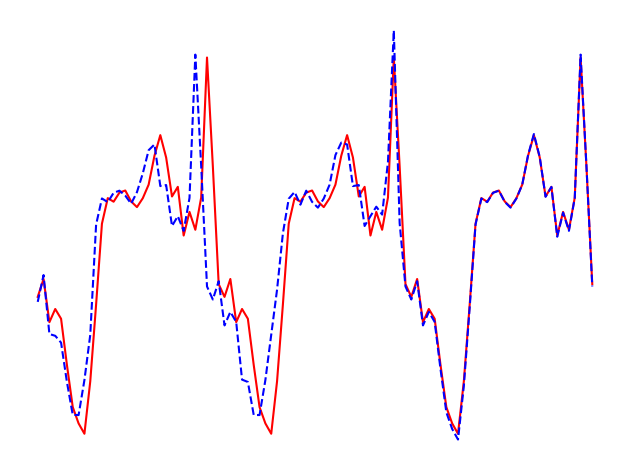

Length of the instance:  96
Number of instances in the query set (target set):  100


In [16]:
instance_idx = 0
plt.plot(trans_uniform_concatenated[instance_idx, :-1], color="red")
plt.plot(trans_random_concatenated[instance_idx, :-1], color="blue", linestyle="--")
plt.axis("off")
plt.tight_layout()
# plt.savefig("../figures/concatenation_uniform_vs_random.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Length of the instance: ", len(trans_uniform_concatenated[instance_idx]) - 1)
print("Number of instances in the query set (target set): ", len(query_set))

# Searching with distance measures provided in aeon

## Precision@k

Compute $P@k$ for querying $Q \in$ `query_set` using `method_name` on `target_set`

In [8]:
# https://www.aeon-toolkit.org/en/latest/api_reference/distances.html
# https://www.aeon-toolkit.org/en/stable/api_reference/auto_generated/aeon.distances.get_distance_function.html
dist_funcs = {
    "squared": get_distance_function("squared"),  # ED
    "dtw": lambda Q, C: get_distance_function("dtw")(Q, C, window=0.1),
    "adtw": lambda Q, C: get_distance_function("adtw")(Q, C, window=0.1),
    "ddtw": lambda Q, C: get_distance_function("ddtw")(Q, C, window=0.1),
    # "erp": lambda Q, C: get_distance_function("erp")(Q, C, window=0.1),
    # "edr": lambda Q, C: get_distance_function("edr")(Q, C, window=0.1),
    # "lcss": lambda Q, C: get_distance_function("lcss")(Q, C, window=0.1),
    # "manhattan": get_distance_function("manhattan"),
    # "minkowski": get_distance_function("minkowski"),
    # "msm": lambda Q, C: get_distance_function("msm")(Q, C, window=0.1),
    # "sbd": get_distance_function("sbd"),
    "shape_dtw": lambda Q, C: get_distance_function("shape_dtw")(Q, C, window=0.1),
    # "twe": lambda Q, C: get_distance_function("twe")(Q, C, window=0.1),
    "wddtw": lambda Q, C: get_distance_function("wddtw")(Q, C, window=0.1),
    "wdtw": lambda Q, C: get_distance_function("wdtw")(Q, C, window=0.1),
}

In [9]:
for dist_name, dist_func in dist_funcs.items():
    # start = time.time()
    precision_at_1, precision_at_3, precision_at_5, precision_at_7 = 0, 0, 0, 0
    for i in range(0, len(query_set)):
        # Strip index
        query_feat = query_set[i][:-1]
        query_idx = query_set[i][-1]
        
        # Target set has index at -1, features up to -1.
        # Strip target features for distance calculation
        distances = np.array([dist_func(query_feat, x[:-1]) for x in target_set])

        # Find true match index (where target index matches query index)
        # Note: target_set[:, -1] creates a view if contiguous, or copy if not. 
        # Since we just need to search, it's fine.
        true_match_pos = np.where(target_set[:, -1] == query_idx)[0][0]

        precision_at_1 += precision_at_k(distances, true_match_pos, 1)
        precision_at_3 += precision_at_k(distances, true_match_pos, 3)
        precision_at_5 += precision_at_k(distances, true_match_pos, 5)
        precision_at_7 += precision_at_k(distances, true_match_pos, 7)
    print(
        f"{precision_at_1 / len(query_set):.2f} & {precision_at_3 / len(query_set):.2f}",
        end=" & ",
    )
    # end = time.time()
    # elapsed_time = end - start
    # print("Elapsed time for overall distance computation: " + str(elapsed_time))

0.30 & 0.70 & 0.90 & 1.00 & 1.00 & 1.00 & 0.80 & 0.85 & 0.50 & 0.70 & 0.80 & 0.85 & 1.00 & 1.00 & 

# Searching with PSED, PSDTW

In [10]:
# psdtw_prime_vanilla, psdtw_prime_parallel, psdtw_prime_parallel_bsf, psdtw_prime_parallel_bsf_lb, psdtw_prime_parallel_bsf_lb2
dist_method = 0  # 0 for ED, 1 for DTW, 15 for DTW (self-defined)
function_used = psdtw_prime_vanilla

dist_func_pp = lambda Q, C: function_used(
        Q, C, l=l, r=0.0, P=P, dist_method= dist_method
    )
dist_func_p = lambda Q, C: dist_func_pp(Q, C)

In [11]:
def dist_func(Q, C):
    dist, _, _ = dist_func_p(Q, C)
    return dist

In [12]:
# Warmup for numba
dist_func(
    trans_uniform_concatenated[instance_idx][:-1],
    trans_random_concatenated[instance_idx][:-1],
)
start = time.time()
dist_func(
    trans_uniform_concatenated[instance_idx][:-1],
    trans_random_concatenated[instance_idx][:-1],
)
end = time.time()
elapsed_time = end - start
print("Elapsed time for a single distance computation: " + str(elapsed_time))

Elapsed time for a single distance computation: 0.0013110637664794922


## Precision@k

In [13]:
all_distances = []
all_count_dist_calls = []
all_cuts = []
start = time.time()
precision_at_1, precision_at_3, precision_at_5, precision_at_7 = 0, 0, 0, 0
for i in range(0, len(query_set)):
    results = [dist_func_p(query_set[i][:-1], x[:-1]) for x in target_set] # Strip index
    dist_arr, count_dist_calls_arr, cuts_arr = zip(*results)
    distances = np.array(dist_arr)

    # store per-iteration results
    all_distances.append(distances)
    all_count_dist_calls.append(count_dist_calls_arr)
    all_cuts.append(cuts_arr)

    # Find true match position
    query_idx = query_set[i][-1]
    target_idxs = target_set[:, -1]
    true_match_pos = np.where(target_idxs == query_idx)[0][0]

    precision_at_1 += precision_at_k(distances, true_match_pos, 1)
    precision_at_3 += precision_at_k(distances, true_match_pos, 3)
    # precision_at_5 += precision_at_k(distances, true_match_pos, 5)
    # precision_at_7 += precision_at_k(distances, true_match_pos, 7)
print(
    f"{precision_at_1 / len(query_set):.2f} & {precision_at_3 / len(query_set):.2f}",
    end=" & ",
)
end = time.time()
elapsed_time = end - start
print()
print("Elapsed time: " + str(elapsed_time))
print("Average Elapsed time: " + str(elapsed_time / len(query_set)))

total_count_dist_calls = 0
for r in all_count_dist_calls:
    total_count_dist_calls += np.sum(r)
print("Total distance measure calls: " + str(total_count_dist_calls))
total_count_dist_calls_original = total_count_dist_calls

1.00 & 1.00 & 
Elapsed time: 0.5761711597442627
Average Elapsed time: 0.028808557987213136
Total distance measure calls: 3429468


In [14]:
os.makedirs("../outputs", exist_ok=True)
np.savez(
    f"../outputs/{dataset_name}_P{P}_l{l:.2f}_dist_method{dist_method}_{function_used.__name__}.npz",
    all_distances=np.array(all_distances, dtype=object),
    all_count_dist_calls=np.array(all_count_dist_calls, dtype=object),
    all_cuts=np.array(all_cuts, dtype=object),
    precision_at_1=precision_at_1 / len(query_set),
    precision_at_3=precision_at_3 / len(query_set),
    precision_at_5=precision_at_5 / len(query_set),
    precision_at_7=precision_at_7 / len(query_set),
    elapsed_time=elapsed_time,
)

# Searching with Cut-based distance

## Import computed cuts

In [17]:
dist_method = 0  # 0 for ED, 1 for DTW, 15 for DTW (self-defined)
# function_used: psdtw_prime_vanilla, psdtw_prime_parallel
function_used = psdtw_prime_vanilla

In [18]:
data = np.load(
    f"../outputs/{dataset_name}_P{P}_l{l:.2f}_dist_method{dist_method}_{function_used.__name__}.npz",
    # f"../outputs_old/{dataset_name}_P{P}_l{l:.2f}_dist_method{dist_method}_{function_used.__name__}.npz",
    allow_pickle=True,
)

all_distances = np.ascontiguousarray(data["all_distances"], dtype=np.float64)
all_count_dist_calls = np.ascontiguousarray(
    data["all_count_dist_calls"], dtype=np.float64
)
all_cuts = np.ascontiguousarray(data["all_cuts"], dtype=np.float64)

In [19]:
# PSED/PSDTW
print(
    f"{data["precision_at_1"]:.2f}",
    f"{data["precision_at_3"]:.2f}",
    end=" & ",
    # f"{data["precision_at_5"]:.2f}",
    # f"{data["precision_at_7"]:.2f}",
)
# print(
#     f"{precision_at_1 / len(query_set):.2f} & {precision_at_3 / len(query_set):.2f}",
#     end=" & ",
# )
print()
print("Elapsed time:", data["elapsed_time"])

total_count_dist_calls = 0
for r in all_count_dist_calls:
    total_count_dist_calls += np.sum(r)
print("Total distance measure calls: " + str(total_count_dist_calls))

0.81 0.88 & 
Elapsed time: 68.36146569252014
Total distance measure calls: 367078356.0


## Compute Cut-based distances

In [20]:
# 0: aeon_squared_distance, 1: aeon_dtw_distance, 2: aeon_adtw_distance, 3: aeon_ddtw_distance, 4: aeon_erp_distance, 5: aeon_edr_distance
# 6: aeon_lcss_distance, 7: aeon_manhattan_distance, 8: aeon_minkowski_distance, 9: aeon_msm_distance, 10: aeon_sbd_distance
# 11: aeon_shape_dtw_distance, 12: aeon_twe_distance, 13: aeon_wddtw_distance, 14: aeon_wdtw_distance
# for i in range(0, 15):
for i in [1, 2, 3, 11, 13, 14]:
    # print("dist_method: " + str(i))
    dist_method = i
    precision_at_1, precision_at_3, precision_at_5, precision_at_7 = 0, 0, 0, 0
    for i in range(0, len(query_set)):
        query_vec = query_set[i][:-1]
        query_idx = query_set[i][-1]
        target_idxs = target_set[:, -1]
        true_match_pos = np.where(target_idxs == query_idx)[0][0]

        distances = np.array(
            [
                cut_based_distance(
                    query_vec,
                    target_set[j][:-1], # Strip index
                    0.1,
                    l,
                    P,
                    dist_method=dist_method,
                    # cuts=all_cuts[i][j],
                    cuts=all_cuts[i][j],
                )
                for j in range(0, len(target_set))
            ]
        )
        precision_at_1 += precision_at_k(distances, true_match_pos, 1)
        precision_at_3 += precision_at_k(distances, true_match_pos, 3)
        # precision_at_5 += precision_at_k(distances, true_match_pos, 5)
        # precision_at_7 += precision_at_k(distances, true_match_pos, 7)
    print(
        f"{precision_at_1 / len(query_set):.2f} & {precision_at_3 / len(query_set):.2f}",
        end=" & ",
    )
    # print(
    #     f"{precision_at_1 / len(query_set):.2f}",
    #     f"{precision_at_3 / len(query_set):.2f}",
    # )

0.73 & 0.84 & 0.80 & 0.88 & 0.54 & 0.68 & 0.81 & 0.88 & 0.53 & 0.69 & 0.73 & 0.84 & 

# Nearest neighbor search with bsf

In [19]:
r = 0.0
l = 1.5
P = 3
dist_method = 0
function_used = psdtw_prime_parallel_bsf

In [20]:
# Warmup for numba
start = time.time()
nearest_neighbor_search(query_set[0][:-1], target_set[:, :-1], r=r, l=l,  P=P, dist_method=dist_method, dist_func=function_used)
end = time.time()
elapsed_time = end - start
print(elapsed_time)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


4.4735801219940186


In [21]:
print("Starting nearest neighbor search over the entire query set...")
print(dataset_name)
all_count_dist_calls = []
start = time.time()
precision_at_1 = 0
for i in range(0, len(query_set)):
    query_vec = query_set[i][:-1]
    target_vecs = target_set[:, :-1]
    best_idx, bsf, total_dist_calls = nearest_neighbor_search(query_vec, target_vecs, r=r, l=l,  P=P, dist_method=dist_method, dist_func=function_used)
    all_count_dist_calls.append(total_dist_calls)
    
    # Check correctness using index
    if target_set[best_idx, -1] == query_set[i, -1]:
        precision_at_1 += 1
print(
    f"{precision_at_1 / len(query_set):.2f}",
    end=" & ",
)
end = time.time()
elapsed_time = end - start
print()
print("Elapsed time: " + str(elapsed_time))
print("Average Elapsed time: " + str(elapsed_time / len(query_set)))

total_count_dist_calls = 0
for r in all_count_dist_calls:
    total_count_dist_calls += np.sum(r)
print("Total distance measure calls: " + str(total_count_dist_calls))
total_count_dist_calls_new = total_count_dist_calls
pruned_dist_calls = total_count_dist_calls_original - total_count_dist_calls_new
pruned_dist_calls_percentage = pruned_dist_calls / total_count_dist_calls_original * 100
print(f"Pruned distance measure calls: {pruned_dist_calls} ({pruned_dist_calls_percentage:.2f}%)")

Starting nearest neighbor search over the entire query set...
SonyAIBORobotSurface1
1.00 & 
Elapsed time: 0.19314193725585938
Average Elapsed time: 0.00965709686279297
Total distance measure calls: 888021
Pruned distance measure calls: 2541447 (74.11%)


In [22]:
import datetime

print(f"This notebook was last run end-to-end on: {datetime.datetime.now()}\n")
###
###
###

This notebook was last run end-to-end on: 2026-03-04 15:46:54.591679

